# <a href="https://thetahat.ru/courses/bm-hf-2026-spr">Математическая статистика (ФБМФ, ФМХФ)</a>
## Домашнее задание 1 &mdash; часть A

**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить по ссылке "Сдача ДЗ" на странице курса. 
* Дедлайн см. на сайте и в боте. После дедлайна работы не принимаются **вообще никак**, кроме случаев наличия уважительной причины.
* До дедлайна можно поменять решение любое количество раз. 
* Любую уважительную причину нужно подтвердить документально, отправив скан или фото боту. При этом работу можно сдать позже на столько дней, на сколько время ее действия пересекается с временем выполнения задания.
* Прислать нужно **ноутбук в формате ipynb**. Другие форматы не принимаются.
* Выполнять задание необходимо **полностью самостоятельно**. При обнаружении списывания **все участники списывания будут сдавать устный зачет.**
* Решения, размещенные на каких-либо интернет-ресурсах не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Простой или основной уровень вы выбираете самостоятельно, выполняя или не выполняя задания типа B. При выборе **простого уровня** достаточно выполнить задания *типа A*. При выборе **основного уровня** нужно выполнять *как задания типа A, так и задания типа B*.
* Для выполнения задания используйте этот ноутбук в качествие основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек. Ячейки с assert'ами **удалять и изменять нельзя**, в противном случае соответствующее задание не будет оценено.
* Комментарии к решению пишите в markdown-ячейках.
* **Если код студента недописан и т.д., то он не оценивается.**
* Каждая задача стоит **5 баллов**.

_Замечание: перед выполнением задания можно ознакомиться с <a href="https://thetahat.ru/courses/bm-hf-2026-spr/stat/2/seminar2">ноутбуком с семинара</a>._

<font size="5">Данная часть задания проверяется автоматически. Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек. Ячейки с assert'ами <b>удалять и изменять нельзя</b>, в противном случае соответствующее задание *не будет оценено*.</font>


> *Примечание.* Рекомендуется работать с данным ноутбуком **локально** в <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/02_jupyter.html">Jupyter Notebook</a> (например, используя <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/01_anaconda.html#Anaconda">Anaconda</a> или <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/02_jupyter.html#6.-Другие-редакторы">альтернативные варианты</a>). Если вы используете софт по типу Google Colaboratory, то перед отправкой боту данного ноутбука необходимо проверить, что **в ячейках с assert'ами и "# Ваше решение тут"** в метаданных присутствуют поля *metadata* с `nbgrader`. Можно открыть ноутбук с решением в текстовом редакторе (MS Word, Блокнот) и выполнить поиск по документу слова `nbgrader`. Если поиск показал ровно **25 совпадений** &mdash; можете отправлять файл боту. Если совпадений меньше, решение может быть не оценено. В таком случае попробуйте скачать файл в форме `ipynb` еще раз и перенесите решения в новый файл. **Внимание! Бот не проверяет решение и не проверяет наличие метаданных.** 

In [ ]:
# Bot check

# HW_ID: st_1a
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то.

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше.
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную.
# Никакие значения в этой ячейке не влияют на факт сдачи работы.

In [4]:
import numpy as np
import scipy.stats as sps
import matplotlib.pyplot as plt
from scipy.special import factorial, gammaln

### Задача 1.1

Пусть $X_1, ..., X_n$ &mdash; выборка пуассоновского распределения $Pois(\theta)$, то есть $\mathsf{P}(X_i = k) = \frac{\theta^k}{k!} e^{-\theta}$ при $k \in \{0, 1, 2, ...\}$.
Реализуйте функции, вычисляющие:
* логарифм правдоподобия;
* градиент логарифма правдоподобия;
* оценку $\theta$ по методу максимального правдоподобия.

_Замечание: функция вычисления логарифма факториала уже реализована ниже_

*Примечание:* вам могут пригодиться методы библиотеки <a href="https://thetahat.ru/courses/python/03">NumPy</a> для работы с массивами и <a href="https://thetahat.ru/courses/python/05">numpy.random или scipy.stats</a> &mdash; со случайными величинами. Задача с семинара <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/seminar2.html#Задача-1.">о распределениях.</a> Задача с семинара <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/seminar2.html#Задача-3.">о работе с массивами.</a>

In [21]:
# L = mult(theta^x_i*exp(-theta)/x_i!
# log(l) = sum (x_i*ln(theta) - theta - ln(x_i!) просто по формулам
# gard log L = (по тета) sun (x_i/teta - 1) = sum(x_i)/teta - n

In [17]:
def logfactorial(x):
    return gammaln(x + 1)

In [18]:
def poiss_loglikelihood(x, theta):
    return np.sum(x * np.log(theta) - theta - logfactorial(x))


-4.333783332753631


In [19]:
x = np.array([1, 2, 3])
assert round(poiss_loglikelihood(x, 1.9), 2) == -4.33
assert poiss_loglikelihood(x, 1.9) > poiss_loglikelihood(x, 4.2)

In [20]:
def poiss_loglikelihood_grad(x, theta):
    return np.sum(x / theta - 1)

In [23]:
x = np.array([1, 2, 3])
assert round(poiss_loglikelihood_grad(x, 1.9), 2) == 0.16

In [24]:
def poiss_maxlikelihood_estimator(x):
    return np.mean(x)

In [25]:
x = np.array([1, 2, 3])
theta = poiss_maxlikelihood_estimator(x)
assert np.allclose(poiss_loglikelihood_grad(x, theta), 0)
assert np.allclose(poiss_maxlikelihood_estimator(x), 2)

### Задача 1.2

Дана выборка $X_1, ..., X_n$ из нормального распределения $\mathcal{N}(a, \sigma^2)$. Реализуйте функции, вычисляющие:
* логарифм правдоподобия для параметра $\theta = (a, \sigma)$;
* градиент логарифма правдоподобия $\theta$;
* оценку $\theta$ по методу максимального правдоподобия.

*Примечание:* вам могут пригодиться методы библиотеки <a href="https://thetahat.ru/courses/python/03">NumPy</a> для работы с массивами и <a href="https://thetahat.ru/courses/python/05">numpy.random или scipy.stats</a> &mdash; со случайными величинами. Задача с семинара <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/seminar2.html#Задача-1.">о распределениях.</a> Задача с семинара <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/seminar2.html#Задача-3.">о работе с массивами.</a>

In [28]:
def norm_loglikelihood(x, a, sigma):
    n = len(x)
    return np.sum(
        -np.log(sigma)
        - 0.5 * np.log(2 * np.pi)
        - (x - a) ** 2 / (2 * sigma ** 2)
    )

In [29]:
x = np.array([1, 2, 3])
assert round(norm_loglikelihood(x, 0, 1), 2) == -9.76
assert norm_loglikelihood(x, 0, 1) < norm_loglikelihood(x, 1, 1)
assert norm_loglikelihood(x, 0, 1) > norm_loglikelihood(x, 0, 100)

In [31]:
def norm_loglikelihood_grad(x, a, sigma):
    n = len(x)
    
    grad_a = np.sum((x - a) / sigma ** 2)
    grad_sigma = -n / sigma + np.sum((x - a) ** 2 / sigma ** 3)
    
    return np.array([grad_a, grad_sigma])

In [32]:
x = np.array([1, 2, 3])
assert np.allclose(norm_loglikelihood_grad(x, 1.9, 3), [0.03, -0.92], atol=0.01)

In [33]:
def norm_maxlikelihood_estimator(x):
    a = np.mean(x)
    sigma = np.sqrt(np.mean((x - a) ** 2))
    
    return a, sigma

In [ ]:
x = np.array([1, 2, 3])
a, sigma = norm_maxlikelihood_estimator(x)
assert np.allclose(norm_loglikelihood_grad(x, a, sigma), 0)
assert np.allclose([a, sigma], [2.00, 0.82], atol=0.01)

---

__________________
### Задача 2.1
Даны 6 параметрических моделей &mdash; для каждой нужно реализовать подсчёт функции правдоподобия по небольшой выборке, чтобы затем построить график функции правдоподобия.

*a).* Параметрическая модель $\mathcal{N}(\theta, 1)$.

*b).* Параметрическая модель $Exp(\theta)$.

*c).* Параметрическая модель $U[0, \theta]$.

*d).* Параметрическая модель $Bin(5, \theta)$.

*e).* Параметрическая модель $Pois(\theta)$.

*f).* Параметрическая модель $Сauchy(\theta)$, где $\theta$ — параметр сдвига.

*Примечание:* вам могут пригодиться методы библиотеки <a href="https://thetahat.ru/courses/python/03">NumPy</a> для работы с массивами и <a href="https://thetahat.ru/courses/python/05">numpy.random или scipy.stats</a> &mdash; со случайными величинами. </a>Для построения графиков используется <a href="https://thetahat.ru/courses/python/04">Matplotlib</a>.

In [35]:
def calc_likelihood(dist_name, theta_grid, sample):
    theta_grid = theta_grid.reshape((-1, 1))
    sample = sample.reshape((1, -1))

    if dist_name == "normal":
        return sps.norm(loc=theta_grid).pdf(sample).prod(axis=1)

    elif dist_name == "expon":
        return sps.expon(scale=theta_grid).pdf(sample).prod(axis=1)

    elif dist_name == "uniform":
        return sps.uniform(loc=0, scale=theta_grid).pdf(sample).prod(axis=1)

    elif dist_name == "binomial":
        return sps.binom(n=5, p=theta_grid).pmf(sample).prod(axis=1)

    elif dist_name == "poisson":
        return sps.poisson(mu=theta_grid).pmf(sample).prod(axis=1)

    elif dist_name == "cauchy":
        return sps.cauchy(loc=theta_grid).pdf(sample).prod(axis=1)

    assert False

In [36]:
check_values = {
 'normal': {'sample': [-1, 1], 'theta': [1.0, 2.0], 'likelihood': [0.0215, 0.0011]},
 'expon': {'sample': [1, 2], 'theta': [6.0, 7.0], 'likelihood': [0.0168, 0.0133]},
 'uniform': {'sample': [0.2, 0.8], 'theta': [1.8, 2.1], 'likelihood': [0.3086, 0.2268]},
 'binomial': {'sample': [5, 5], 'theta': [0.6, 0.7], 'likelihood': [0.006, 0.0282]},
 'poisson': {'sample': [5, 10], 'theta': [6.04, 7.03], 'likelihood': [0.0068, 0.0091]},
 'cauchy': {'sample': [-0.5, 0.5], 'theta': [1.0, 2.0], 'likelihood': [0.0249, 0.0043]}
}
for dist_name, params in check_values.items():
    ans = calc_likelihood(dist_name, np.array(params["theta"]), np.array(params["sample"]))
    ref = np.array(params["likelihood"])
    assert ans.shape == ref.shape
    assert np.allclose(ans, ref, atol=1e-4)

Посмотрим на графики функций правдоподобия:

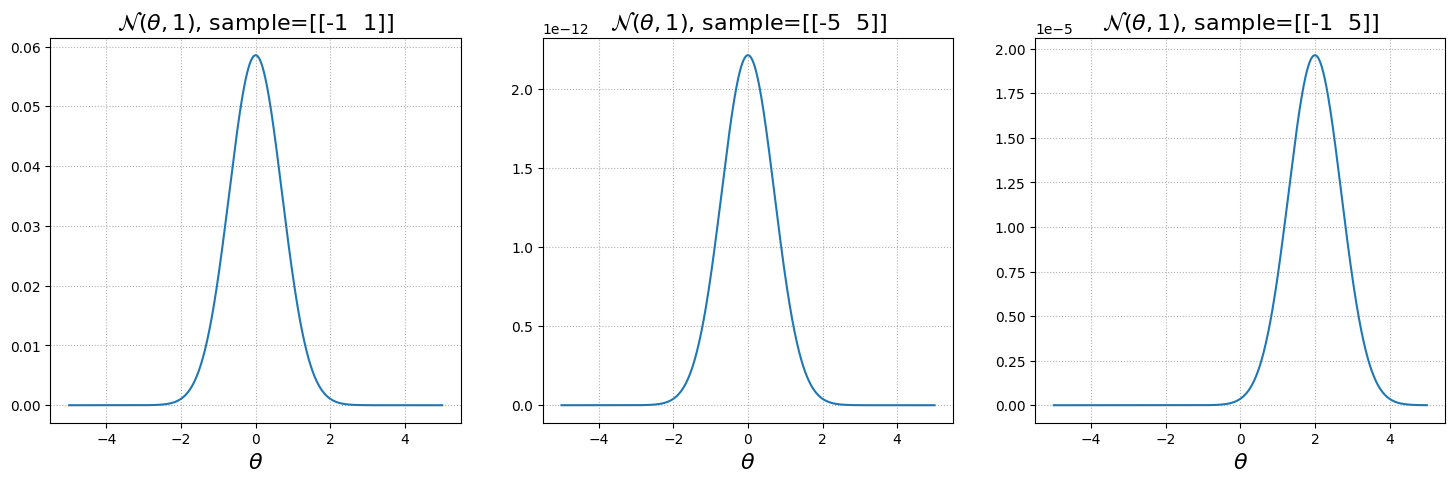

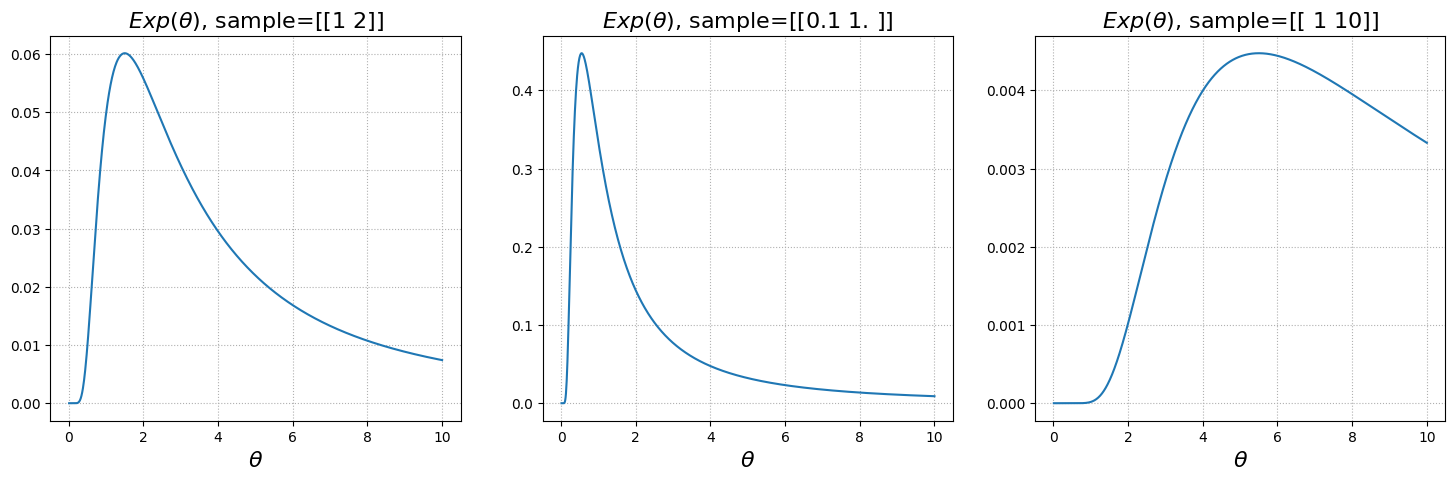

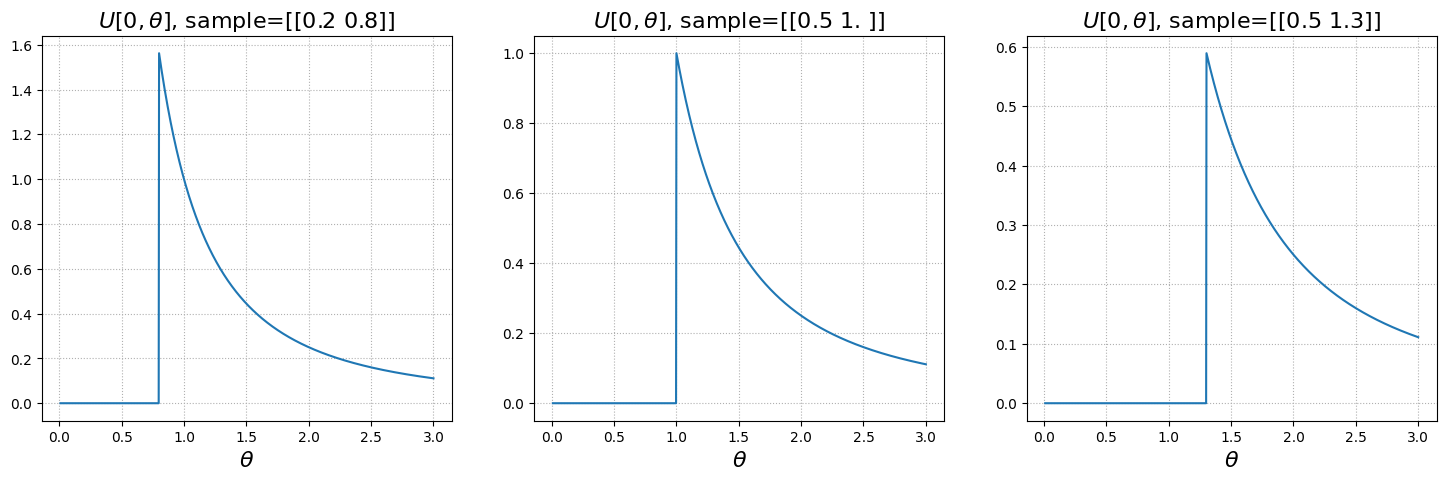

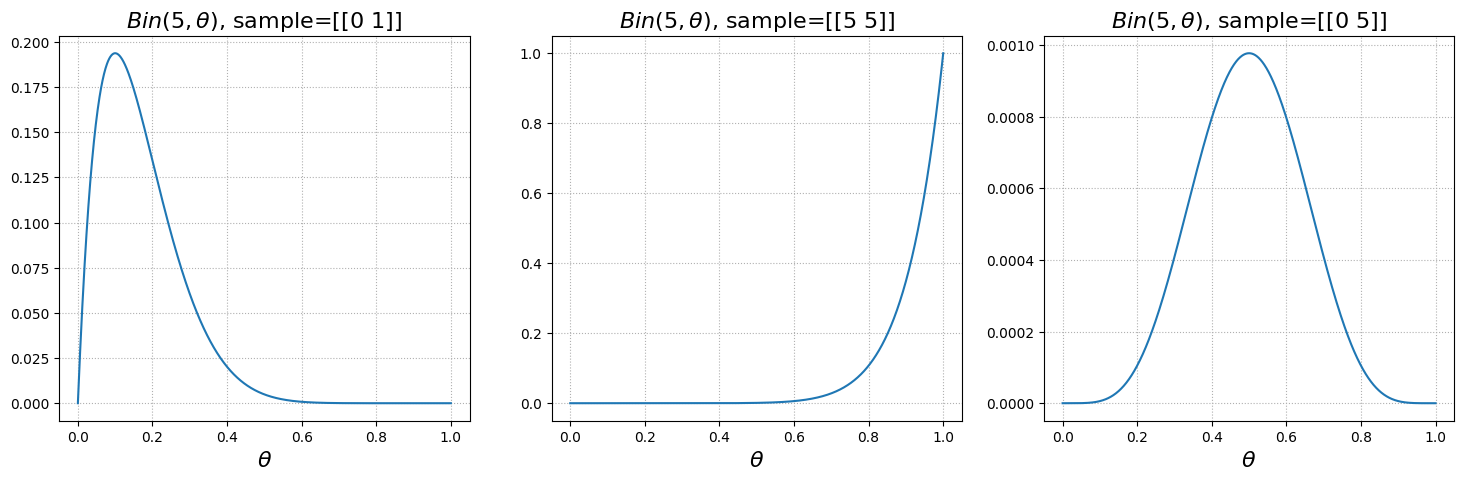

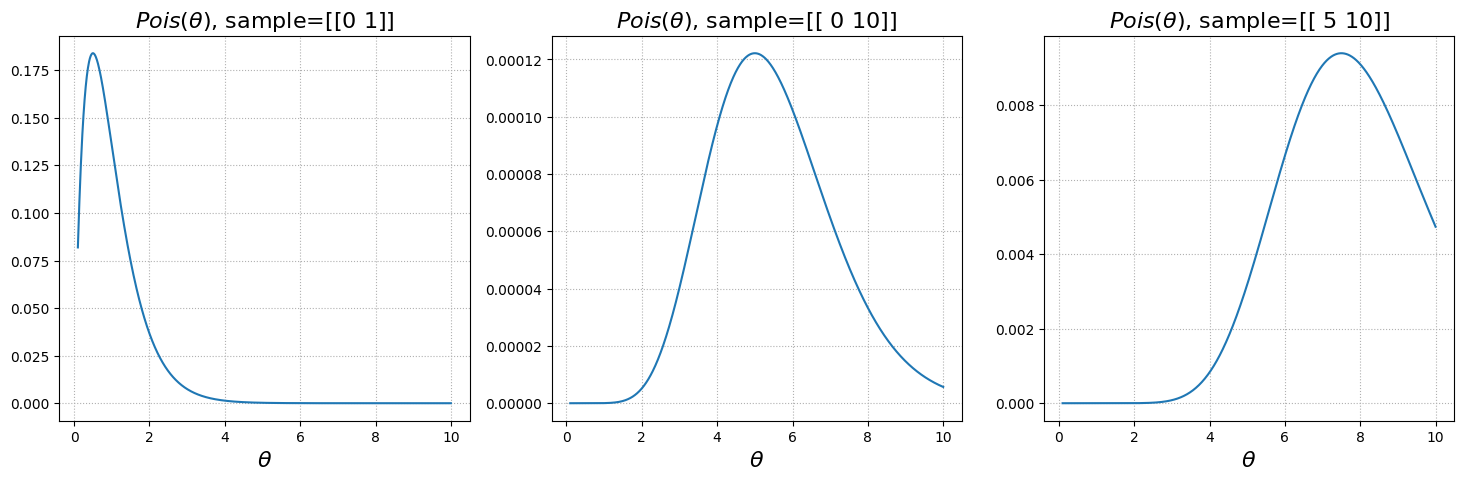

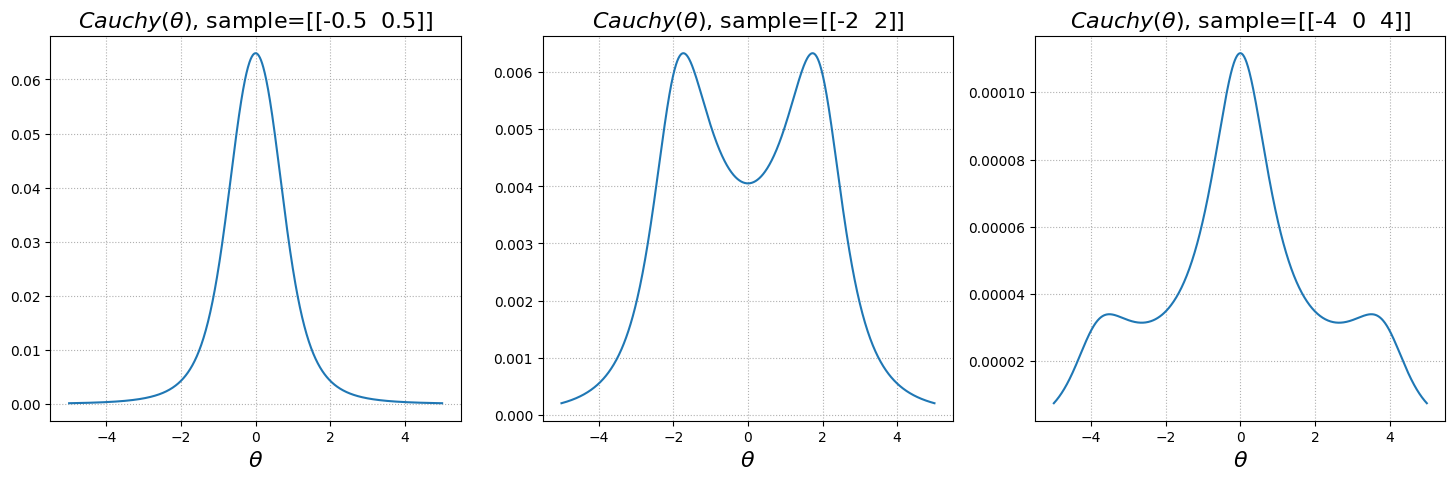

In [37]:
dist2samples = {
    "normal":   [[-1, 1], [-5, 5], [-1, 5]],
    "expon":    [[1, 2], [0.1, 1], [1, 10]],
    "uniform":  [[0.2, 0.8], [0.5, 1], [0.5, 1.3]],
    "binomial": [[0, 1], [5, 5], [0, 5]],
    "poisson":  [[0, 1], [0, 10], [5, 10]],
    "cauchy":   [[-0.5, 0.5], [-2, 2], [-4, 0, 4]],
}
dist2grid = {
    "normal":   np.linspace(-5, 5, 1000),
    "expon":    np.linspace(0.01, 10, 1000),
    "uniform":  np.linspace(0.01, 3, 1000),
    "binomial": np.linspace(0, 1, 1000),
    "poisson":  np.linspace(0.1, 10, 1000),
    "cauchy":   np.linspace(-5, 5, 1000),
}
dist2label = {
    "normal":   r"$\mathcal{N}(\theta, 1)$",
    "expon":    r"$Exp(\theta)$",
    "uniform":  r"$U[0, \theta]$",
    "binomial": r"$Bin(5, \theta)$",
    "poisson":  r"$Pois(\theta)$",
    "cauchy":   r"$Сauchy(\theta)$",
}

for dist_name in dist2samples.keys():
    label = dist2label[dist_name]

    plt.figure(figsize=(18, 5))
    grid = dist2grid[dist_name]
    for i, sample in enumerate(dist2samples[dist_name]):
        sample = np.array(sample).reshape((1, -1))
        likelihood = calc_likelihood(dist_name, grid, sample)

        plt.subplot(1, 3, i+1)
        plt.plot(grid, likelihood)
        plt.xlabel('$\\theta$', fontsize=16)
        plt.grid(ls=':')
        plt.title(label + ', sample=' + str(sample), fontsize=16)
    plt.show()

Сделайте вывод о том, как функция правдоподобия для каждой модели зависит от выборки.

**Вывод:**

Что мы вообще сделали? Имея пару параметров берем очень много тета и все проверяем (хорошая вообще практика, но очень затратная на больших обьемах (ух, помню как тренил кучу моделей с матрицами гипер параметров на DLS)) и показали на графиках "оптимальные" параметры тета для всех распределений и параметров
По распределениям
1) для нормальноголучше всего подходит то тета, которое ближе к среднему распределений это нули или 2
2) экспоненицальное, в нем тета тоже задает среднее, тоже совпадает максимум с тета равному среднему
3) для равномерного распределения x не больше тета, иначе вообще не верно, а при тета равному x лучше всего укладывается
4) тут тета определяет верпоятность успеха, экспериментов всегда 5, а значит при тета равном mean(x)/5 будет максимум
5) тета также задает среднее, прии тета равном среденму sample будет максимум
6) тут интеренснее, из-за тяжелых хвостов распределения коши может быть выгодно ставить центр на одно из значений, так как расхождения от двух хвостов относительно центра менее выгодно, яем один хвост на 4 может быть два максимума, обьясним по подробнее
L = mult(1/(pi*(1+(x_i-teta)^2), тогда берем значения x_i = -2, 2; teta = 2, 0, -2 имеем следующее (1/(1+2^2))^2 или 1*1/(1 + 4^2)) == 1/25 или 1/17, на двойках выгоднее, чем на нуле 

Является ли функция правдоподобия плотностью? Имеет ли она единственный максимум? Дайте ответы на эти вопросы в переменных следующей ячейке, записав в соответствующую переменную либо название распределения, для которого это свойство не выполняется (если таких несколько, можете вписать любое), либо `None`, если свойство верно всегда.

In [38]:
# функция правдоподобия вообще не является плотностью по theta
non_density = 'normal' # еще на коши явно меньше единицы, так как 0.006*10 != 1

# видно на коши
has_single_maximum = 'cauchy'

In [39]:
assert non_density in [None, 'normal', 'expon', 'uniform', 'binomial', 'poisson', 'cauchy']
assert has_single_maximum in [None, 'normal', 'expon', 'uniform', 'binomial', 'poisson', 'cauchy']
# А тут скрытые assert'ы :)

### Задача 2.2

Дана функция, которая по выборке $(X_1, \ldots, X_n)$ и двум числам $\mu_0, \mu_1$ определяет, какое из двух распределений &mdash; $\mathcal{N}(\mu_0, 1)$ или $\mathcal{N}(\mu_1, 1)$ &mdash; более точно описывает выборку, путём сравнения функций правдоподобия:

In [40]:
def select(x, u0, u1):
    prob0 = sps.norm(loc=u0).pdf(x).prod()
    prob1 = sps.norm(loc=u1).pdf(x).prod()
    if prob0 > prob1:
        return 0
    else:
        return 1

Пример работы для выборки размера 30 из $\mathcal{N}(0.1, 1)$:

In [41]:
np.random.seed(1)

In [42]:
select(sps.norm(loc=0.1).rvs(30), u0=0, u1=1)

0

In [43]:
select(sps.norm(loc=0.1).rvs(30), u0=1, u1=0)

1

Однако она некорректно работает для выборок большого размера:

In [44]:
select(sps.norm(loc=0.1).rvs(1000), u0=0, u1=1) # returns 1

1

In [45]:
select(sps.norm(loc=0.1).rvs(1000), u0=1, u1=0) # returns 0

1

Почему такое происходит?

**Ответ:**

Стоит сказать, что плотность нормального распределоения как правило меньше 0.5, что при подсчете L от тета как mult(f(tetf, x_i)) дает перемножения чисел меньше единицы самих на себя, для маленькой выборки это не критично, 10e-30 (0.1^30) хранится во float32, а вот 10^-1000 уже нет, тогда всегда будет вылезать 1 по логике функции


Напишите исправленную версию функции, которая также выбирает подходящий параметр на основе значения правдободобия, но работает и для выборок большого размера.

_Подсказка: обратите внимание на значения функций правдоподобия при маленькой и большой выборке. Нужно использовать некоторый метод класса `sps.norm` модуля <a href="https://thetahat.ru/courses/python/05">scipy.stats</a>._

In [46]:
def select_fixed(x, u0, u1): # хел е логарифмы превращают в отрицательные числа, а не очень маленькие
    logprob0 = sps.norm(loc=u0).logpdf(x).sum()
    logprob1 = sps.norm(loc=u1).logpdf(x).sum()

    if logprob0 > logprob1:
        return 0
    else:
        return 1

In [47]:
x = sps.norm(loc=0.1).rvs(1000)
assert select_fixed(x, u0=0, u1=1) == 0
assert select_fixed(x, u0=1, u1=0) == 1

### Задача 3
В этой задаче нужно визуально проверить *свойство состоятельности*.

Пусть $X_1, ..., X_n$ &mdash; выборка из распределения $U(0, \theta)$.

Рассмотрим 5 оценок $\theta$:
- $\widehat{\theta}_a = 2\overline{X}$
- $\widehat{\theta}_b = \max_i X_i$
- $\widehat{\theta}_c = 2\sqrt{\overline{X^2}}$
- $\widehat{\theta}_d = \sqrt{3\overline{X^2}}$
- $\widehat{\theta}_e = (n + 1) \min_i X_i$

Дано множество выборок $X^1, \dots, X^{300}$ из распределения $U[0, 1]$:  $\; X^j = (X^j_1, \dots, X^j_{500}), 1 \leqslant j \leqslant 300$.
<br>
По каждой из них посчитайте оценки

$\widehat{\theta}_{a,jn} = 2\frac{X^j_1 + \dots + X^j_n}{n}$,
$\widehat{\theta}_{b,jn} = \max(X^j_1, \dots, X^j_n)$,
$\widehat{\theta}_{c,jn} = 2 \cdot \sqrt{\frac{\sum_{i=1}^n {X_{ji}^2}}{n}}$ и т.д.,

для $1 \leqslant n \leqslant 500$,  то есть оценки параметра $\theta$ по первым $n$ наблюдениям $j$-й выборки. При написании кода могут помочь функции `numpy.cumsum(axis=...)` и `np.maximum.accumulate(axis=...)` (см. пример в <a href="https://thetahat.ru/files/bm-hf-2026-spr/stat/2/seminar2.html#Задача-4.">ноутбуке с семинара</a>).

In [53]:
x = sps.uniform().rvs((300, 500))

n = np.arange(1, 501)

estimations = [
    2 * np.cumsum(x, axis=1) / n,
    np.maximum.accumulate(x, axis=1),
    2 * np.sqrt(np.cumsum(x ** 2, axis=1) / n),
    np.sqrt(3 * np.cumsum(x ** 2, axis=1) / n),
    3 * np.minimum.accumulate(x, axis=1),
]
x.shape

(300, 500)

In [49]:
assert np.allclose(estimations[0][42, 1], 2 * (x[42, 0] + x[42, 1]) / 2)
assert np.allclose(estimations[1][42, 1], max(x[42, 0], x[42, 1]))
assert np.allclose(estimations[2][42, 1], 2 * ((x[42, 0]**2 + x[42, 1]**2) / 2)**0.5)
assert np.allclose(estimations[3][42, 1], (3 * (x[42, 0]**2 + x[42, 1]**2) / 2)**0.5)
assert np.allclose(estimations[4][42, 1], 3 * min(x[42, 0], x[42, 1]))
assert len(estimations) == 5
assert all(estimations[i].shape == (300, 500) for i in range(5))

Для каждой оценки $\theta^*, \widehat{\theta}$ нарисуйте следующий график. Для каждого $j$ нанесите на один график зависимости $\theta^*_{jn}$ или $\widehat{\theta}_{jn}$ от $n$ с помощью `plt.plot`. Каждая кривая должна быть нарисована *одним цветом* с прозрачностью `alpha=0.05`. Поскольку при малых $n$ значения средних могут быть большими по модулю, ограничьте область графика по оси *y* с помощью функции `plt.ylim((min, max))`. Примеры работы с графиками с помощью Matplotlib можно найти в <a href="https://thetahat.ru/files/python/04_matplotlib.html#Библиотека-matplotlib">этом ноутбуке</a>.

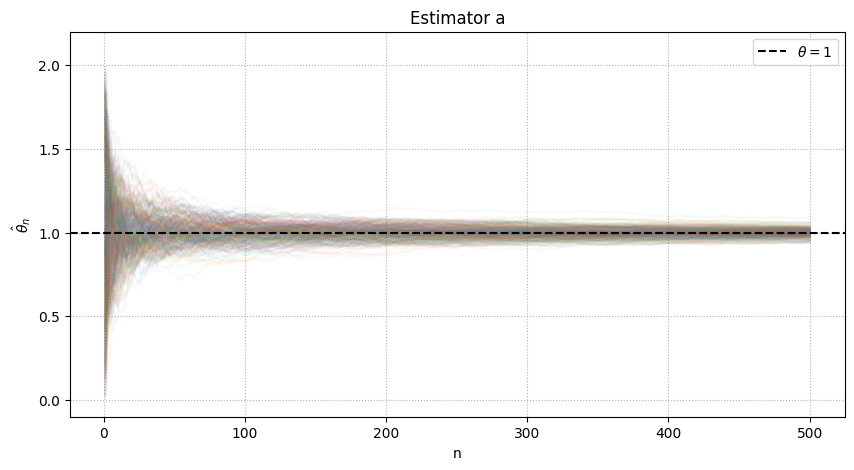

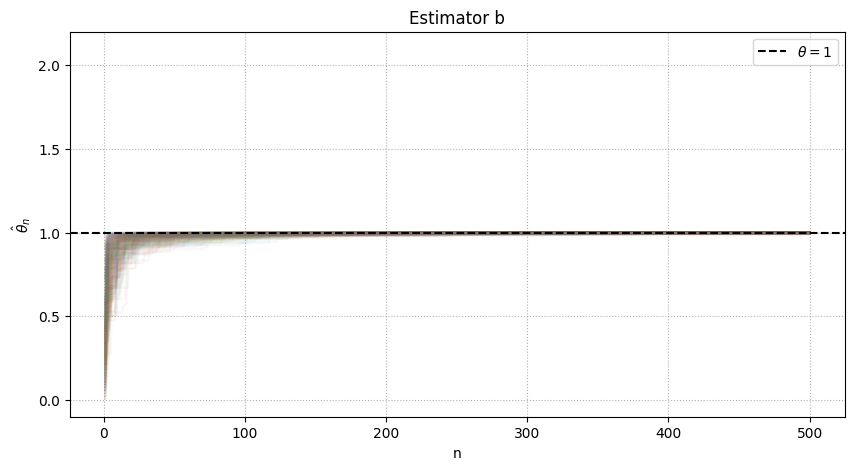

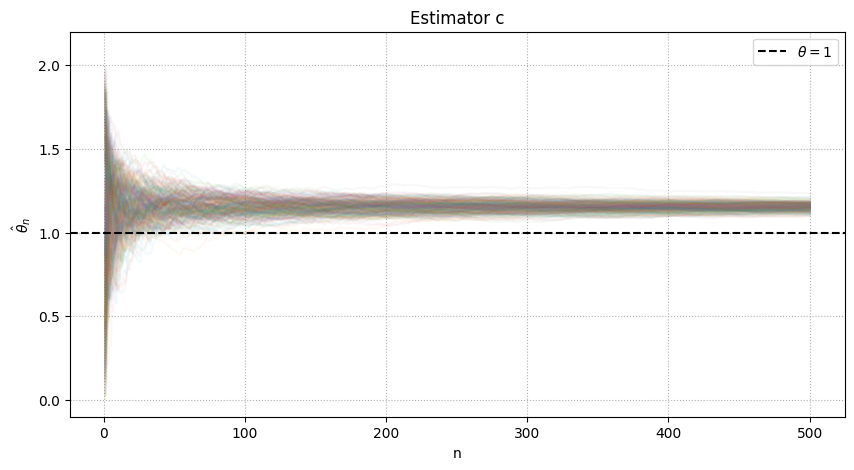

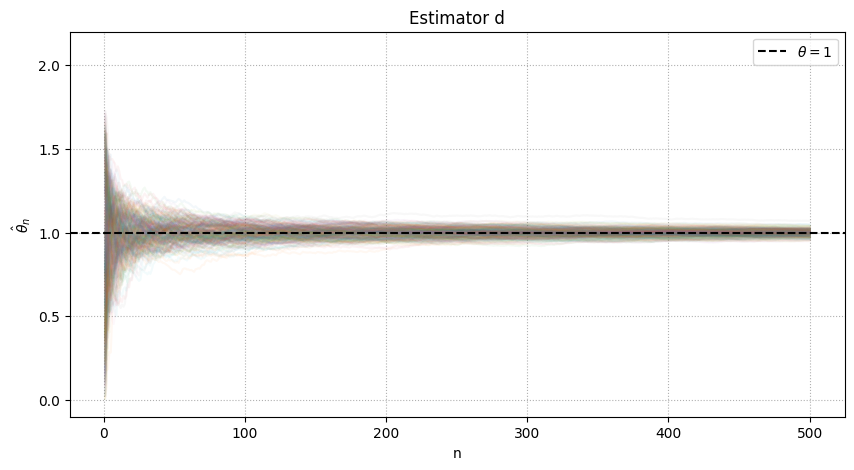

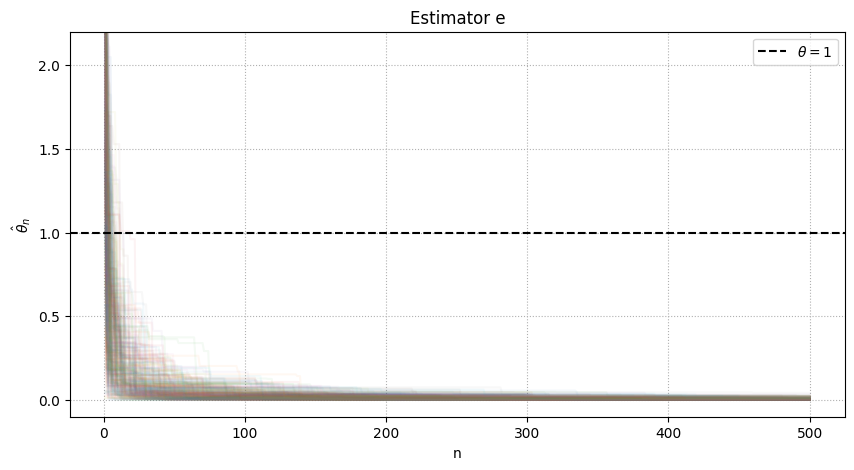

In [50]:
names = ["a", "b", "c", "d", "e"]

for estimation, name in zip(estimations, names):
    plt.figure(figsize=(10, 5))

    for i in range(300):
        plt.plot(n, estimation[i], alpha=0.05)

    plt.axhline(1, color="black", linestyle="--", label=r"$\theta = 1$")
    plt.xlabel("n")
    plt.ylabel(r"$\hat{\theta}_n$")
    plt.title(f"Estimator {name}")
    plt.ylim(-0.1, 2.2)
    plt.grid(ls=":")
    plt.legend()
    plt.show()

Укажите, для каких оценок, судя по графику, наблюдается свойство состоятельности:
все просто - линии крутятся вокруг teta = 1 => состоятельна, это когда оценка тета совпадает с реальным

In [ ]:
consistent_estimators = {"a", "b", "d"}

In [ ]:
assert isinstance(consistent_estimators, set)
assert consistent_estimators <= {"a", "b", "c", "d", "e"}
# А тут скрытые assert'ы :)

---
© 2026 команда <a href="https://thetahat.ru/">ThetaHat</a> для Статистики ФБМФ и ФЭФМ